# Spectral decomposition closure 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, compute_variance, put_fig_letter

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DT = 3
distance_to_coast_max = 20e3

In [3]:
band = ['', 'LF', 'inertial', 'diurnal', 'semidiurnal', 'HF']

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = 'spectral_decomp',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list =[update_dict(base_dic, {'drifter_preprocess_param':b}) for b in band]


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0 = ds0.where(ds0.depth==0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

# Correct mean geostrophic
df0 = ds0.to_dataframe().reset_index().set_index('row_number')

#DEPTH 15M
base_dic = update_dict(base_dic, {'wd_depth':'15'})

comb_list = [update_dict(base_dic, {'drifter_preprocess_param':b}) for b in band]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15 =ds15.where(ds15.depth==15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

# Correct mean geostrophic
df15 = ds15.to_dataframe().reset_index().set_index('row_number')

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0__inertial__swot2km_fromduacsv__fromduacsv__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0__semidiurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0__HF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
307771
12h_spectral_decomp_all_med_variational_10min_v0__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
307771
12h_spectral_decomp_all_med_variational_10min_v0__inertial__swot2km_fromduacsv__fromduacsv__era5

In [4]:
ds0['id_comb'] = ['all'] + band[1:]
ds15['id_comb'] = ['all'] + band[1:]

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<DT).dropna('row_number')
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)
ds = (compute_variance(DS)/U2).rename({'id_comb':'Frequency band'})

In [5]:
df = ds.to_dataframe().reset_index()
df['Frequency band'] = ['All', 'LF', 'Inertial', 'Diurnal', 'Semidiurnal', 'HF']
df = df.set_index('Frequency band')

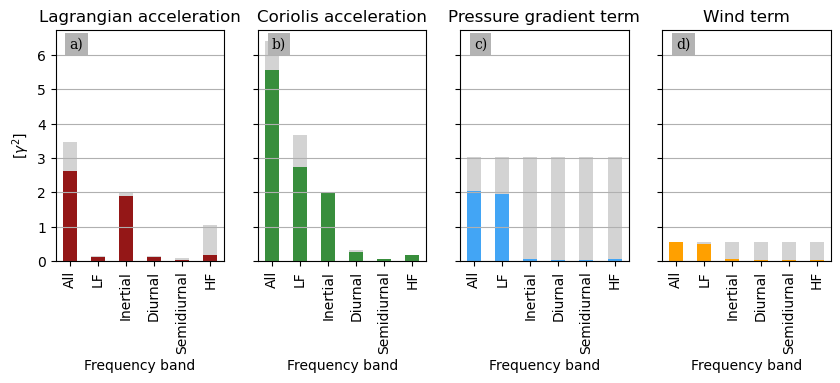

In [6]:
vars = ['acc', 'cor', 'ggd','wd']
title={'acc' : 'Lagrangian acceleration', 'cor':'Coriolis acceleration', 'ggd':'Pressure gradient term','wd':'Wind term'}
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1, 4, figsize = (10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)): 
    ax=axs[j]
    df['E_'+vars[j]].plot.bar(ax=ax, color= 'lightgrey', bottom = df['B_'+vars[j]])
    df['B_'+vars[j]].plot.bar(ax=ax, color= c0[vars[j]])
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_title(title[vars[j]])

i=0
for l in ['a', 'b', 'c', 'd'] :
    put_fig_letter(fig, axs[i], l)
    i+=1
    

In [7]:
df.E_cor

Frequency band
All            0.844422
LF             0.906295
Inertial      -0.034308
Diurnal        0.033228
Semidiurnal   -0.013207
HF            -0.038005
Name: E_cor, dtype: float64

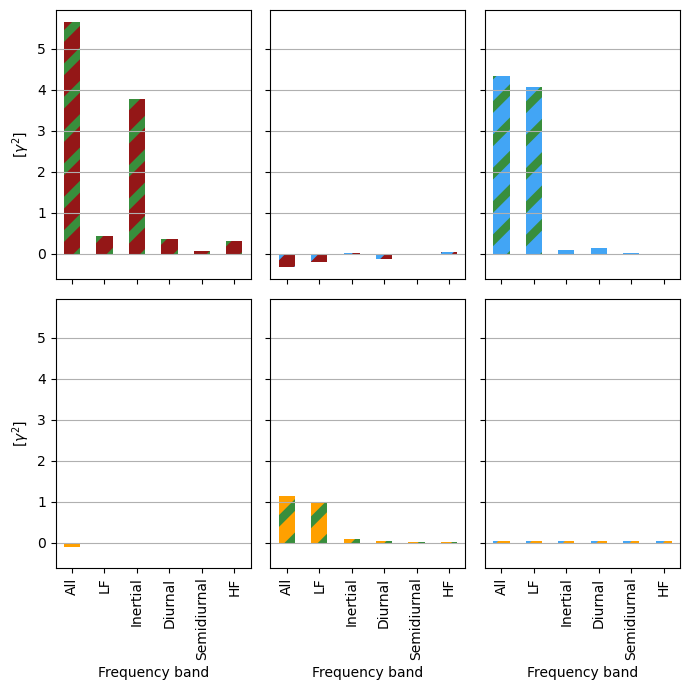

In [8]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(2, 3, figsize = (7, 7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

ax=axs[0]
plt.rcParams["hatch.color"] = c0['cor']
df.X_acc_cor.plot.bar(color = c0['acc'], hatch="/", ax=ax)

ax=axs[1]
plt.rcParams["hatch.color"] = c0['ggd']
df.X_acc_ggd.plot.bar(color = c0['acc'], hatch="/", ax=ax)

ax=axs[2]
plt.rcParams["hatch.color"] = c0['cor']
df.X_cor_ggd.plot.bar(color = c0['ggd'], hatch="/", ax=ax)

ax=axs[3]
plt.rcParams["hatch.color"] = c0['acc']
df.X_acc_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax)

ax=axs[4]
plt.rcParams["hatch.color"] = c0['cor']
df.X_cor_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax)

ax=axs[5]
plt.rcParams["hatch.color"] = c0['ggd']
df.X_ggd_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax)

for ax in axs :
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')

fig.tight_layout()

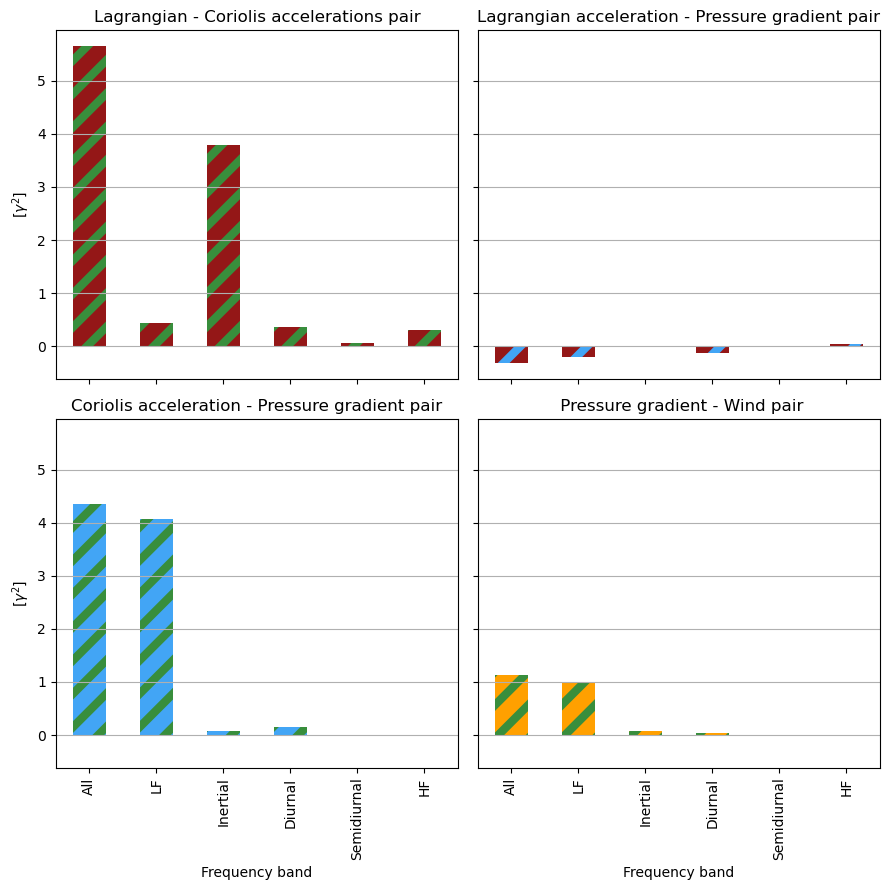

In [11]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(2, 2, figsize = (9, 9), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

ax=axs[0]
plt.rcParams["hatch.color"] = c0['cor']
df.X_acc_cor.plot.bar(color = c0['acc'], hatch="/", ax=ax)
ax.set_title('Lagrangian - Coriolis accelerations pair')

ax=axs[1]
plt.rcParams["hatch.color"] = c0['ggd']
df.X_acc_ggd.plot.bar(color = c0['acc'], hatch="/", ax=ax)
ax.set_title('Lagrangian acceleration - Pressure gradient pair')

ax=axs[2]
plt.rcParams["hatch.color"] = c0['cor']
df.X_cor_ggd.plot.bar(color = c0['ggd'], hatch="/", ax=ax)
ax.set_title('Coriolis acceleration - Pressure gradient pair')

#ax=axs[3]
#plt.rcParams["hatch.color"] = c0['acc']
#df.X_acc_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax)

ax=axs[3]
plt.rcParams["hatch.color"] = c0['cor']
df.X_cor_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax)
ax.set_title(' Pressure gradient - Wind pair')

#ax=axs[5]
#plt.rcParams["hatch.color"] = c0['ggd']
#df.X_ggd_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax)

for ax in axs :
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')

fig.tight_layout()

## Frequency bandm

In [4]:
def cpd_to_hours(x): return 24/x

In [11]:
cpd_to_hours(0.88), cpd_to_hours(1.05), cpd_to_hours(1.75), cpd_to_hours(1.9), cpd_to_hours(2.1)

(27.272727272727273,
 22.857142857142858,
 13.714285714285714,
 12.631578947368421,
 11.428571428571429)